# Feature engineering

 Cél: olyan mintázatok feltárása, amelyek később előrejelzési modell (forecasting) építéséhez használhatók. Illetve olyan featurek hozzáadása, amit a domain vizsgálat igazol.

 basic: location,datetime,latitude,longitude,no2,pm10,pm25,so2,temperature,humidity,wind_speed,precipitation

## Importok

A szükséges könyvtárak betöltése:

1. pandas, numpy: adatkezelés
2. matplotlib: vizualizáció
3. statsmodels: idősoros elemzés (autokorreláció)
4. joblib: adatmentés
5. PCA és KMeans: a dimenziócsökkentés és klaszterezési lehetőségek elemzéséhez
6. StandardScaler: PCA-nál skálázáshoz, hogy a különbüző értékek ugyanazon a skálán mozogjanak


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
import joblib
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

## Előkészített adatok betöltése

In [2]:
df = pd.read_csv("../data/preprocessed/eda_preprocessed.csv")
df["datetime"] = pd.to_datetime(df["datetime"])
df = df.sort_values(["location", "datetime"])
df = df.set_index("datetime")
df.head()

,location,no2,pm10,pm25,so2,temperature,humidity,wind_speed,precipitation,latitude,longitude
datetime,,,,,,,,,,,
2024-03-01 20:00:00+00:00,Gyor 2 Ifjusag,7.8,37.0,19.0,23.5,8.9,92.0,8.4,0.0,47.67717,17.65782
2024-03-01 21:00:00+00:00,Gyor 2 Ifjusag,13.4,46.0,22.0,23.1,8.1,93.0,7.3,0.0,47.67717,17.65782
2024-03-01 22:00:00+00:00,Gyor 2 Ifjusag,12.4,48.0,19.0,23.3,7.3,95.0,7.0,0.0,47.67717,17.65782
2024-03-01 23:00:00+00:00,Gyor 2 Ifjusag,10.2,40.0,15.0,23.3,6.1,97.0,10.3,0.0,47.67717,17.65782
2024-03-02 00:00:00+00:00,Gyor 2 Ifjusag,8.1,38.0,19.0,22.6,5.4,99.0,9.2,0.0,47.67717,17.65782


## Seasonility

Megvizsgáljuk a mintázatokat:

1. óránként (napi ciklus)
2. hét napjai szerint
3. hónap szerint

Ez segít felismerni:
1. napi ritmust
2. heti trendeket
3. szezonális hatásokat

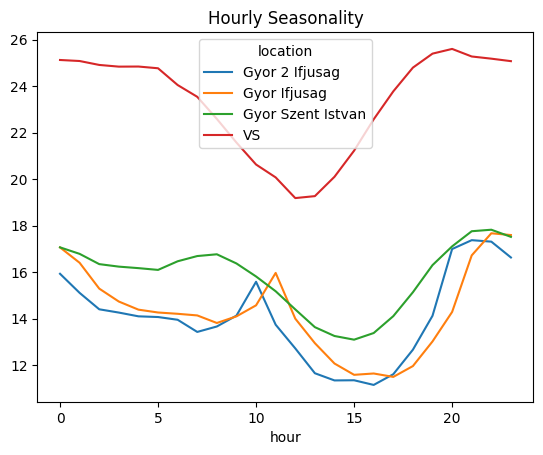

In [3]:
season = df.copy()
season["hour"] = season.index.hour
season.groupby(["location","hour"])["pm25"].mean().unstack(0).plot()
plt.title("Hourly Seasonality")
plt.show()

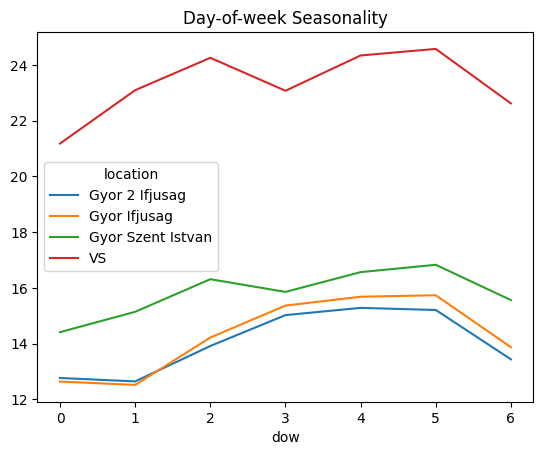

In [4]:
season["dow"] = season.index.dayofweek
season.groupby(["location","dow"])["pm25"].mean().unstack(0).plot()
plt.title("Day-of-week Seasonality")
plt.show()


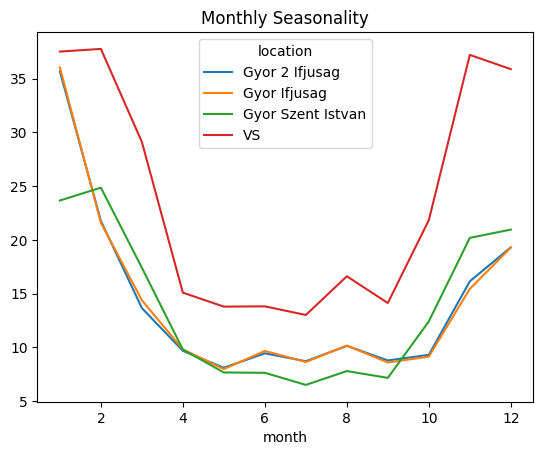

In [5]:
season["month"] = season.index.month
season.groupby(["location","month"])["pm25"].mean().unstack(0).plot()
plt.title("Monthly Seasonality")
plt.show()

## Lag korreláció

Megvizsgáljuk, hogy a PM2.5 mennyire függ a múltbeli értékeitől:

1. különböző késleltetések (lag)
2. autokorreláció

Ez alapja a feature engineeringnek (lag feature-ök).

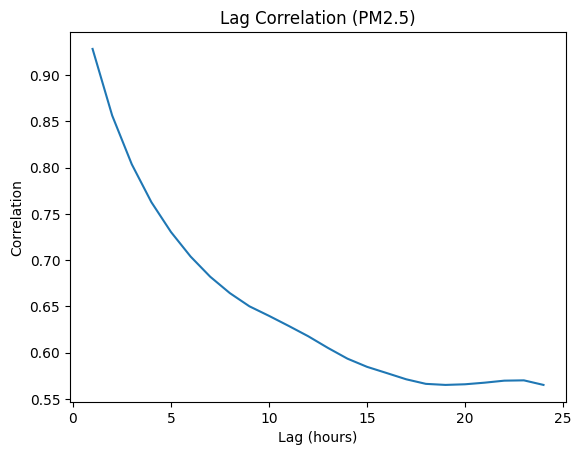

In [6]:
lags = range(1,25)
lag_corr = []

for lag in lags:
    corr = df.groupby("location")["pm25"].apply(
    lambda x: x.corr(x.shift(lag))
).mean()
    lag_corr.append(corr)

plt.plot(lags, lag_corr)
plt.xlabel("Lag (hours)")
plt.ylabel("Correlation")
plt.title("Lag Correlation (PM2.5)")
plt.show()


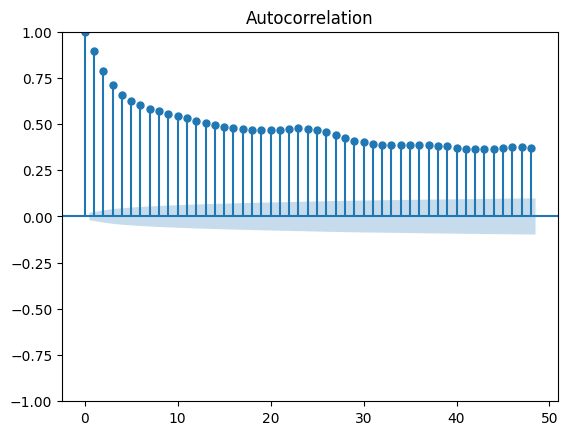

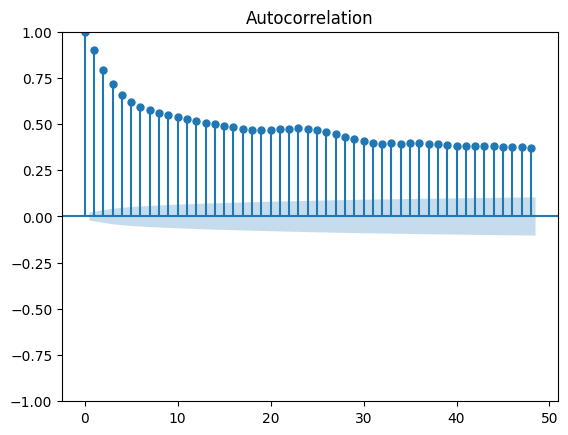

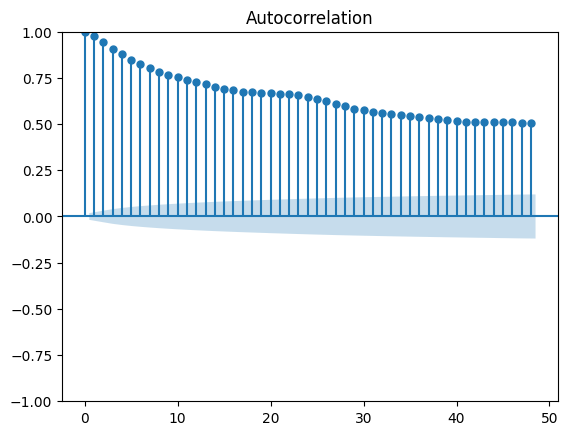

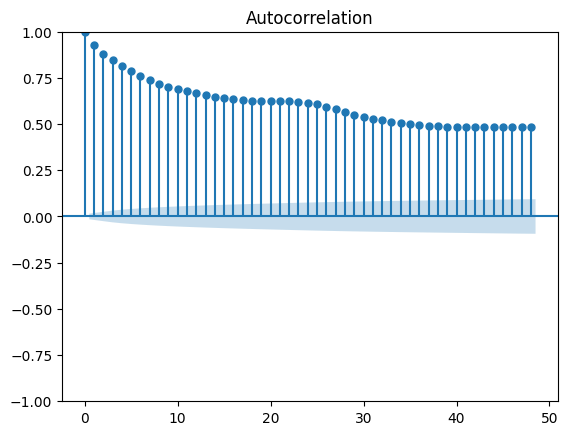

In [7]:
for loc in df["location"].unique():
    plot_acf(df[df["location"]==loc]["pm25"].dropna(), lags=48)
plt.show()


## Új feature-öket hozunk létre

Ezek a múltbeli értékeket adják hozzá a modellhez, ami kulcsfontosságú idősoros predikciónál.

1. pm25_lag1	előző óra PM2.5
2. pm25_lag3	3 órával korábbi érték
3. pm25_lag6	6 órával korábbi érték
4. pm25_lag24	tegnap ugyanebben az órában
5. pm25_roll6	utolsó 6 óra átlaga
6. pm25_roll24	utolsó 24 óra átlaga
7. pm25_trend_3h	3 órás változás iránya
8. pm25_std_12h	12 órás szórás

In [8]:
df["pm25_lag1"] = df.groupby("location")["pm25"].shift(1)
df["pm25_lag3"] = df.groupby("location")["pm25"].shift(3)
df["pm25_lag6"] = df.groupby("location")["pm25"].shift(6)
df["pm25_lag24"] = df.groupby("location")["pm25"].shift(24)

In [9]:
df["pm25_roll6"] = (
    df.groupby("location")["pm25"]
    .rolling(6)
    .mean()
    .groupby("location")
    .shift(1)
    .reset_index(level=0, drop=True)
)

df["pm25_roll24"] = (
    df.groupby("location")["pm25"]
    .rolling(24)
    .mean()
    .groupby("location")
    .shift(1)
    .reset_index(level=0, drop=True)
)

df["pm25_trend_3h"] = df.groupby("location")["pm25"].diff(3)

df["pm25_std_12h"] = (
    df.groupby("location")["pm25"]
    .rolling(12)
    .std()
    .groupby("location")
    .shift(1)
    .reset_index(level=0, drop=True)
)

### Time features

1. hour	napszak (0–23)
2. hour_sin	ciklikus napszak komponens
3. hour_cos	ciklikus napszak komponens
4. month	évszak jelleg
5. month_sin	ciklikus éves komponens
6. month_cos	ciklikus éves komponens
7. weekend_flag	hétvége bináris jelző
8. heating_season_flag fűtési időszak

In [10]:
df["hour"] = df.index.hour
df["hour_sin"] = np.sin(2*np.pi*df["hour"]/24)
df["hour_cos"] = np.cos(2*np.pi*df["hour"]/24)

df["month"] = df.index.month
df["month_sin"] = np.sin(2*np.pi*df["month"]/12)
df["month_cos"] = np.cos(2*np.pi*df["month"]/12)

df["dow"] = df.index.dayofweek
df["weekend_flag"] = (df["dow"] >= 5).astype(int)

df["heating_season_flag"] = df.index.month.isin(
    [10,11,12,1,2,3,4]
).astype(int)

df.drop(columns=["dow"], inplace=True)

### Weather features
1. temp_change_3h	hőmérséklet változás 3 órán belül
2. humidity_change_3h	páratartalom változás 3 órán belül
3. wind_change_3h	szélsebesség változás 3 órán belül
4. stagnation_index	stagnáló légköri állapot mértéke
5. temp_wind_interaction	hőmérséklet és szél kombinációja
6. mixing_index	légkeveredés indikátora
7. ventilation_index	szél + keveredés kombináció
8. stagnation_hours_6h	stagnáló órák száma

In [11]:
df["temp_change_3h"] = (
    df.groupby("location")["temperature"].diff(3)
)

df["humidity_change_3h"] = (
    df.groupby("location")["humidity"].diff(3)
)

df["wind_change_3h"] = (
    df.groupby("location")["wind_speed"].diff(3)
)

df["stagnation_index"] = (
    df["humidity"] / (df["wind_speed"] + 0.5)
)

df["temp_wind_interaction"] = (
    df["temperature"] * df["wind_speed"]
)

df["mixing_index"] = (
    (df["temperature"] + 273.15) *
    (df["wind_speed"] + 1.0) /
    (df["humidity"] + 20.0)
)

df["ventilation_index"] = (
    df["wind_speed"] *
    (df["temperature"] + 273.15)
)

df["low_wind_flag"] = (df["wind_speed"] < 2).astype(int)
df["stagnation_hours_6h"] = (
    df.groupby("location")["low_wind_flag"]
    .rolling(6)
    .sum()
    .groupby("location")
    .shift(1)
    .reset_index(level=0, drop=True)
)

df.drop(columns=["low_wind_flag"], inplace=True)

### SPATIAL

A mérőállomások földrajzi elhelyezkedése befolyásolhatja a légszennyezés mértékét, ezért térbeli információkat is bevonunk a modellbe.

1. LAT_MEAN, LON_MEAN: A lat_norm és lon_norm változók lehetővé teszik, hogy a modell összefüggést tanuljon a földrajzi elhelyezkedés és a légszennyezés között.
3. mapping: Egy numerikus azonosítót rendel minden állomáshoz. (location_id)

In [12]:
LAT_MEAN = df["latitude"].mean()
LON_MEAN = df["longitude"].mean()
df["lat_norm"] = df["latitude"] - LAT_MEAN
df["lon_norm"] = df["longitude"] - LON_MEAN

locations = sorted(df["location"].unique())
mapping = {loc: i for i, loc in enumerate(locations)}

df["location_id"] = df["location"].map(mapping)
# visszaalakítás
#{v:k for k,v in mapping.items()}[2]

### Összes feature

In [13]:
df.columns

Index(['location', 'no2', 'pm10', 'pm25', 'so2', 'temperature', 'humidity',
       'wind_speed', 'precipitation', 'latitude', 'longitude', 'pm25_lag1',
       'pm25_lag3', 'pm25_lag6', 'pm25_lag24', 'pm25_roll6', 'pm25_roll24',
       'pm25_trend_3h', 'pm25_std_12h', 'hour', 'hour_sin', 'hour_cos',
       'month', 'month_sin', 'month_cos', 'weekend_flag',
       'heating_season_flag', 'temp_change_3h', 'humidity_change_3h',
       'wind_change_3h', 'stagnation_index', 'temp_wind_interaction',
       'mixing_index', 'ventilation_index', 'stagnation_hours_6h', 'lat_norm',
       'lon_norm', 'location_id'],
      dtype='str')

In [14]:
FEATURES = [

    # ------------------------------------------------
    # AIR POLLUTION
    # ------------------------------------------------
    "pm10",
    "no2",
    "so2",

    # ------------------------------------------------
    # PM MEMORY
    # ------------------------------------------------
    "pm25_lag1",
    "pm25_lag3",
    "pm25_lag6",
    "pm25_lag24",
    "pm25_roll6",
    "pm25_roll24",
    "pm25_trend_3h",
    "pm25_std_12h",

    # ------------------------------------------------
    # TIME
    # ------------------------------------------------
    "hour",
    "hour_sin",
    "hour_cos",
    "month",
    "month_sin",
    "month_cos",
    "weekend_flag",
    "heating_season_flag",

    # ------------------------------------------------
    # WEATHER CURRENT
    # ------------------------------------------------
    "temperature",
    "humidity",
    "wind_speed",
    "precipitation",

    # ------------------------------------------------
    # WEATHER DYNAMICS
    # ------------------------------------------------
    "temp_change_3h",
    "humidity_change_3h",
    "wind_change_3h",

    # ------------------------------------------------
    # PHYSICAL INTERACTIONS
    # ------------------------------------------------
    "stagnation_index",
    "temp_wind_interaction",
    "mixing_index",
    "ventilation_index",
    "stagnation_hours_6h",

    # ------------------------------------------------
    # SPATIAL
    # ------------------------------------------------
    "location_id",
    "lat_norm",
    "lon_norm"
]

### Ellenőrzés

Minden szerepel e a Feature listában?

In [15]:
missing = [f for f in FEATURES if f not in df.columns]
assert len(missing) == 0, f"Missing features: {missing}"

 ## PCA és CLUSTERING elemzés

Shape for PCA: (19591, 34)


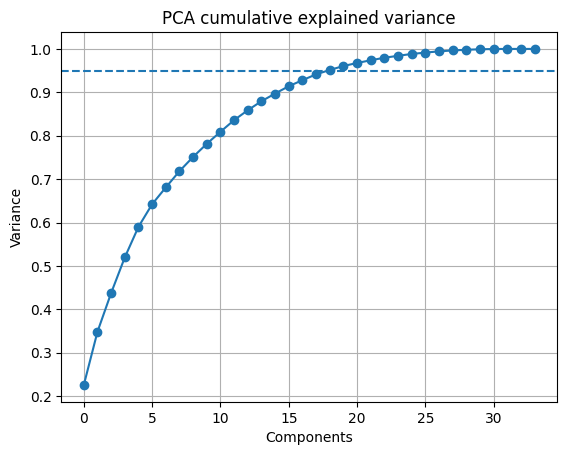

Components for 95% variance: 19


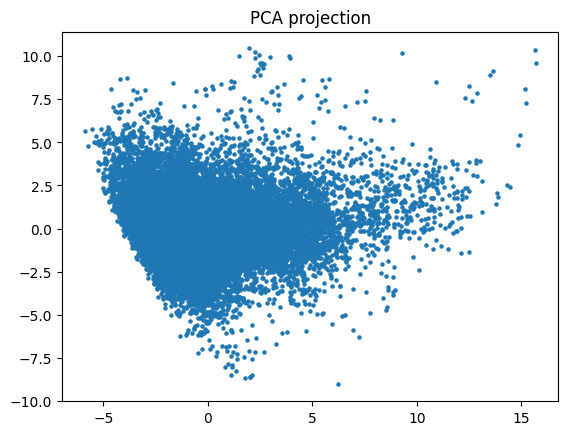

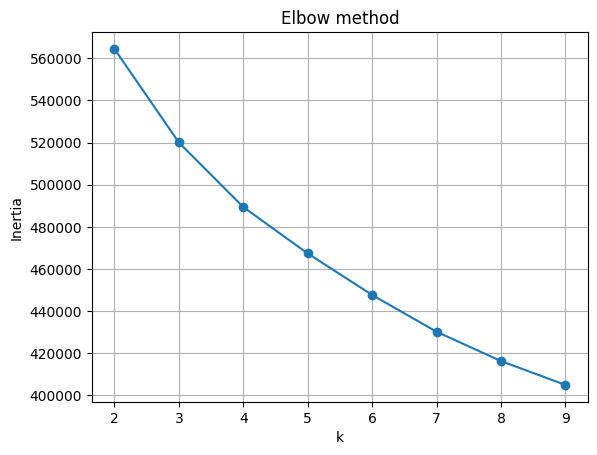

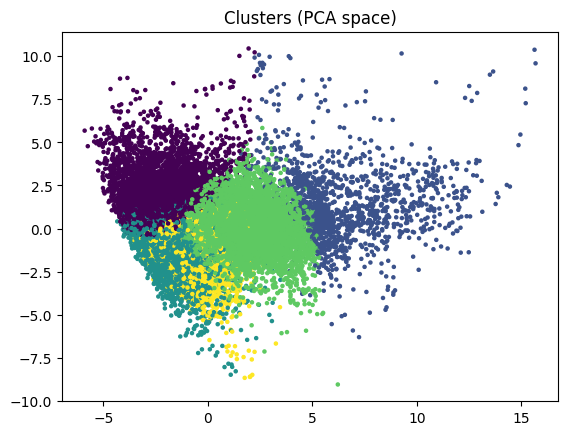

In [16]:
X = df[FEATURES].dropna().copy()

print("Shape for PCA:", X.shape)

# ---------------- PCA ----------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA()
pca.fit(X_scaled)

explained_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure()
plt.plot(explained_variance, marker="o")
plt.axhline(0.95, linestyle="--")
plt.title("PCA cumulative explained variance")
plt.xlabel("Components")
plt.ylabel("Variance")
plt.grid()
plt.show()

n_95 = np.argmax(explained_variance >= 0.95) + 1
print("Components for 95% variance:", n_95)


# ---------------- PCA 2D ----------------
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)

plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=5)
plt.title("PCA projection")
plt.show()


# ---------------- KMeans Elbow ----------------
inertias = []
K_RANGE = range(2, 10)

for k in K_RANGE:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure()
plt.plot(K_RANGE, inertias, marker="o")
plt.title("Elbow method")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.grid()
plt.show()


# ---------------- Clustering viz ----------------
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, s=5)
plt.title("Clusters (PCA space)")
plt.show()

### PCA

A PCA eredmények alapján a variancia jelentős része viszonylag kevés főkomponensben koncentrálódik.

Ez különösen a lag és rolling típusú változók miatt figyelhető meg, amelyek hasonló információt hordoznak különböző időbeli eltolással.

Megfigyelhető egy domináns irány a feature-térben, de a variancia több dimenzióban is eloszlik.

A PCA tehát alkalmas lenne dimenziócsökkentésre, azonban a választott fa-alapú modellek nem igénylik ezt, és az interpretálhatóság megőrzése érdekében a nyers feature-öket használjuk.

### Clustering

Az elbow módszer alapján nem figyelhető meg éles töréspont, ami arra utal, hogy az adatok nem tartalmaznak jól elkülönülő klasztereket.

A klaszterek jelentősen átfednek, ami arra utal, hogy az adatok inkább folytonos szerkezetűek, mint klaszterekből állók.


A clustering nem adott jelentős többletinformációt a modell számára és nem mutatott jól elkülönülő struktúrát.


In [17]:
df.to_parquet("../data/preprocessed/preprocessed_with_FE.parquet")
joblib.dump(FEATURES,"../artifacts/features.pkl")
joblib.dump(mapping, "../artifacts/location_mapping.pkl")
joblib.dump(LAT_MEAN, "../artifacts/lat_mean.pkl")
joblib.dump(LON_MEAN, "../artifacts/lon_mean.pkl")

['../artifacts/lon_mean.pkl']